# ECON 3916: ML Prediction Project — Final Project

**From Question to Recommendation**

This notebook scaffolds your final project. Work through each part sequentially. By Week 12, this notebook (plus your `app.py` and report) will form your complete submission.

**AI Policy:** AI co-pilot is REQUIRED. Document every AI interaction in Part 7 (AI Methodology Appendix) using the P.R.I.M.E. framework.

---

## Part 0: Setup

In [ ]:
# ============================================================
# Part 0: Setup — Run this cell first
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    mean_squared_error, mean_absolute_error, r2_score
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('Setup complete.')

Setup complete.


---
## Part 1: Problem Statement

Fill in each blank below. This becomes the opening paragraph of your report.

**My prediction question is:** Can we predict whether a country will experience a financial crisis based on macroeconomic indicators?

**This is a prediction (umbrella) problem because:** The goal is to forecast whether a crisis occurs using observable economic data, rather than determining whether any single variable causes a crisis. The model focuses on identifying patterns that improve predictive accuracy, not causal relationships.
(Reminder: prediction asks "can we forecast Y from X?" — not "does X cause Y?")

**The decision this enables:** This analysis would help policymakers and international organizations decide when to intervene in vulnerable economies, allowing them to take preventative action before a crisis occurs.
(Who is the stakeholder? What action would they take differently with your prediction?)

**Dataset:** ___ 
- **Source:** 2016_Global_Crisis_data.csv (URL: https://github.com/MohamedataS/Systemic-And-Banking-Crises/blob/master/00-Database/2016_Global_Crisis_Data.csv)
- **N =** 15,190
- **Features =** 16
- **Target variable =** Systemic Crisis
- **Access date:** April 2026

---
## Part 2: Data Loading + EDA

### 2.1 Load Your Data

In [ ]:
# ============================================================
# 2.1 Load your dataset
# ============================================================
# Replace the URL/path below with your data source

df = pd.read_csv('2016_Global_Crisis_Data.csv')

# Quick look
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (15190, 16)
Columns: ['Case', 'CC3', 'Country', 'Year', 'Banking Crisis', 'Systemic Crisis', 'Gold Standard', 'exch_usd', 'Domestic_Debt_In_Default', 'SOVEREIGN EXTERNAL DEBT 1: DEFAULT and RESTRUCTURINGS, 1800-2012--Does not include defaults on WWI debt to United States and United Kingdom and post-1975 defaults on Official External Creditors', 'SOVEREIGN EXTERNAL DEBT 2: DEFAULT and RESTRUCTURINGS, 1800-2012--Does not include defaults on WWI debt to United States and United Kingdom but includes post-1975 defaults on Official External Creditors', 'GDP_Weighted_default', 'Inflation, Annual percentages of average consumer prices', 'Independence', 'Currency Crises', 'Inflation Crises']


,Case,CC3,Country,Year,Banking Crisis,Systemic Crisis,Gold Standard,exch_usd,Domestic_Debt_In_Default,"SOVEREIGN EXTERNAL DEBT 1: DEFAULT and RESTRUCTURINGS, 1800-2012--Does not include defaults on WWI debt to United States and United Kingdom and post-1975 defaults on Official External Creditors","SOVEREIGN EXTERNAL DEBT 2: DEFAULT and RESTRUCTURINGS, 1800-2012--Does not include defaults on WWI debt to United States and United Kingdom but includes post-1975 defaults on Official External Creditors",GDP_Weighted_default,"Inflation, Annual percentages of average consumer prices",Independence,Currency Crises,Inflation Crises
0,1,DZA,Algeria,1800,0.0,0.0,0.0,NaN,0.0,0,0.0,0.0,NaN,0,0,0.0
1,1,DZA,Algeria,1801,0.0,0.0,0.0,NaN,0.0,0,0.0,0.0,NaN,0,0,0.0
2,1,DZA,Algeria,1802,0.0,0.0,0.0,NaN,0.0,0,0.0,0.0,NaN,0,0,0.0
3,1,DZA,Algeria,1803,0.0,0.0,0.0,NaN,0.0,0,0.0,0.0,NaN,0,0,0.0
4,1,DZA,Algeria,1804,0.0,0.0,0.0,NaN,0.0,0,0.0,0.0,NaN,0,0,0.0


In [ ]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace('[^a-z0-9]', '_', regex=True)
    .str.replace('_+', '_', regex=True)
)

In [ ]:
df.columns

Index(['case', 'cc3', 'country', 'year', 'banking_crisis', 'systemic_crisis',
       'gold_standard', 'exch_usd', 'domestic_debt_in_default',
       'sovereign_external_debt_1_default_and_restructurings_1800_2012_does_not_include_defaults_on_wwi_debt_to_united_states_and_united_kingdom_and_post_1975_defaults_on_official_external_creditors',
       'sovereign_external_debt_2_default_and_restructurings_1800_2012_does_not_include_defaults_on_wwi_debt_to_united_states_and_united_kingdom_but_includes_post_1975_defaults_on_official_external_creditors',
       'gdp_weighted_default',
       'inflation_annual_percentages_of_average_consumer_prices',
       'independence', 'currency_crises', 'inflation_crises'],
      dtype='object')

### 2.2 Basic Description

In [ ]:
# ============================================================
# 2.2 Describe your data
# ============================================================

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15190 entries, 0 to 15189
Data columns (total 16 columns):
 #   Column                                                                                                                                                                                                   Non-Null Count  Dtype  
---  ------                                                                                                                                                                                                   --------------  -----  
 0   case                                                                                                                                                                                                     15190 non-null  int64  
 1   cc3                                                                                                                                                                                                 

,case,year,banking_crisis,systemic_crisis,gold_standard,domestic_debt_in_default,sovereign_external_debt_2_default_and_restructurings_1800_2012_does_not_include_defaults_on_wwi_debt_to_united_states_and_united_kingdom_but_includes_post_1975_defaults_on_official_external_creditors,gdp_weighted_default,independence,currency_crises,inflation_crises
count,15190.000000,15190.000000,14615.000000,15119.000000,11280.000000,14478.000000,14534.000000,14315.000000,15190.000000,15190.000000,14820.000000
mean,35.500000,1908.000000,0.055217,0.037502,0.160638,0.022655,0.131210,0.128863,0.670770,0.081698,0.077733
std,20.205862,62.643901,0.228412,0.189996,0.367213,0.148806,0.337641,0.888846,0.469949,0.282900,0.267760
min,1.000000,1800.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,18.000000,1854.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,35.500000,1908.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,53.000000,1962.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,70.000000,2016.000000,1.000000,1.000000,1.000000,1.000000,1.000000,18.930000,1.000000,2.000000,1.000000


The dataset includes 15,190 observations at the country-year level and covers a range of financial and economic indicators. It combines both numeric and categorical variables, including things like exchange rates, inflation, and different types of debt defaults. The target variable, systemic crisis, is binary and indicates whether a country experienced a financial crisis in a given year.

### 2.3 Missing Data Assessment

Missing data (%) by column:
inflation_annual_percentages_of_average_consumer_prices                                                                                                                                                    0.349506
exch_usd                                                                                                                                                                                                   0.315800
gold_standard                                                                                                                                                                                              0.257406
gdp_weighted_default                                                                                                                                                                                       0.057604
domestic_debt_in_default                                                                                                    

/var/folders/j3/nd_86gjn37l6zlf48np5tyx80000gn/T/ipykernel_99901/110626284.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


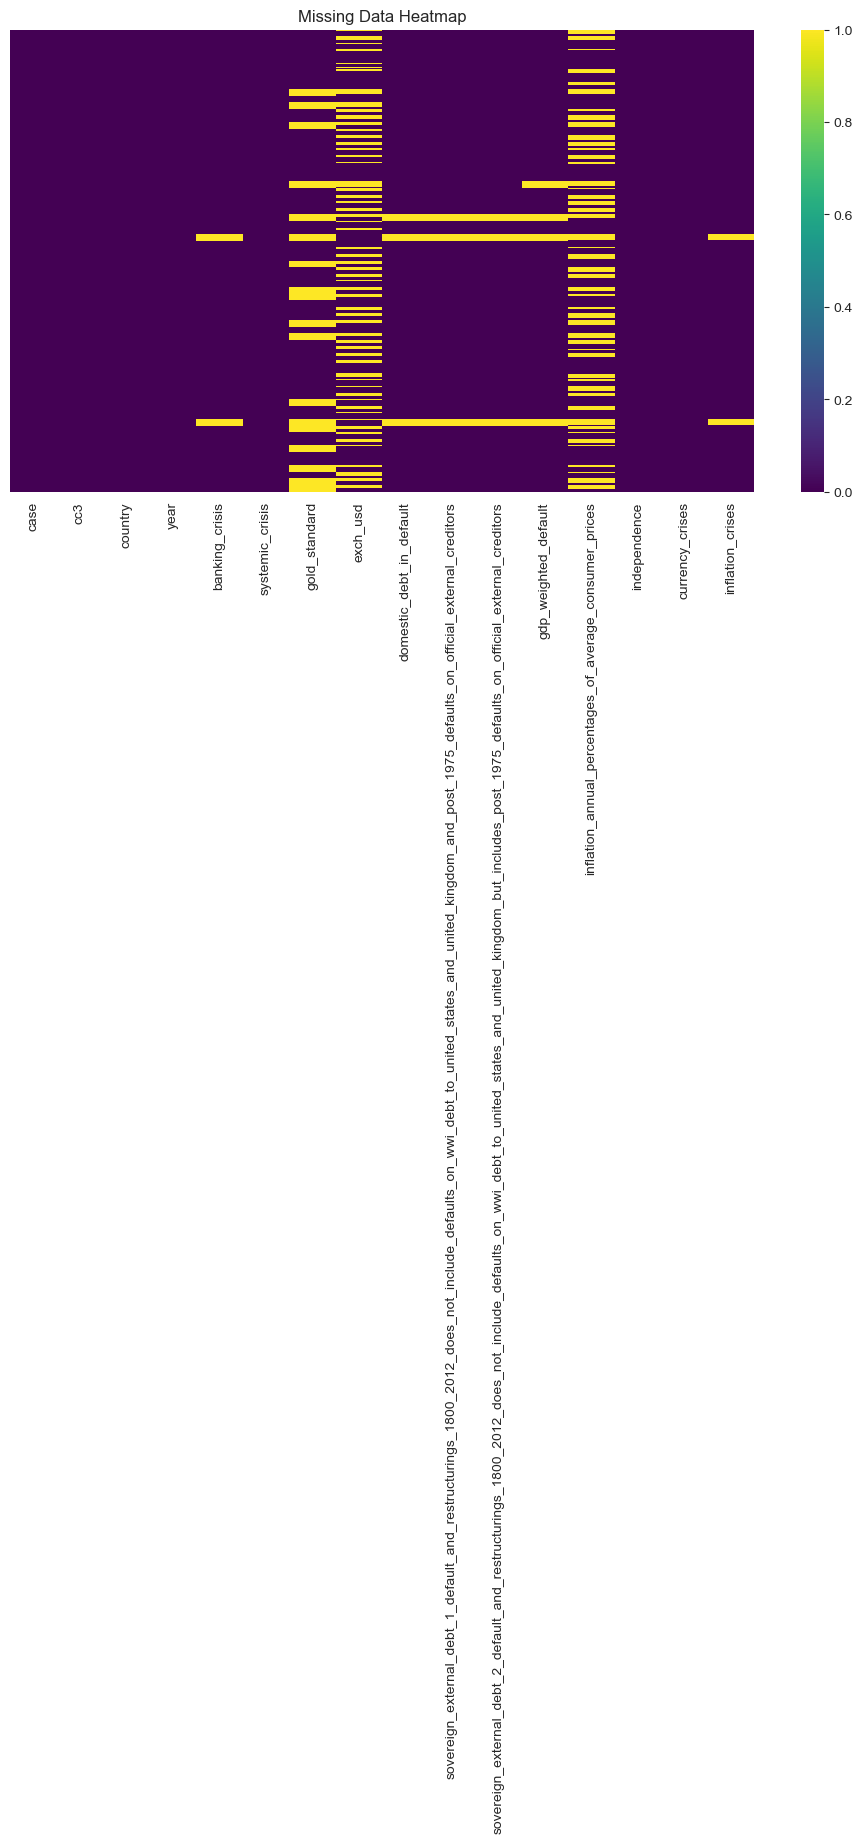

In [ ]:
# ============================================================
# 2.3 Missing data heatmap (Ch 1: MCAR/MAR/MNAR)
# ============================================================

missing_pct = df.isnull().mean().sort_values(ascending=False)
print('Missing data (%) by column:')
print(missing_pct[missing_pct > 0])

# # Visual: missing data heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.tight_layout()
plt.show()

**Missing data strategy:** There is a noticeable amount of missing data across several variables, especially for inflation and exchange rates, where a large share of observations is missing. The missing values are not spread evenly across the dataset, which suggests they are more likely due to differences in data availability across countries and time periods rather than random chance. Because of this, the missingness can be treated as MAR (Missing At Random). To handle it, I plan to use median imputation for numeric variables and keep an eye on whether highly incomplete features are actually useful for prediction.

### 2.4 Distribution Plots

In [62]:
# ============================================================
# 2.4 Distribution of key features (Ch 3)
# ============================================================

# # Plot distributions for your most important features
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(df['inflation_annual_percentages_of_average_consumer_prices'].dropna(), kde=True, ax=axes[0])
axes[0].set_title('Inflation Distribution')

sns.histplot(df['exch_usd'].dropna(), kde=True, ax=axes[1])
axes[1].set_title('Exchange Rate Distribution')

sns.countplot(x='systemic_crisis', data=df, ax=axes[2])
axes[2].set_title('Systemic Crisis (Target)')

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

### 2.5 Outlier Detection

In [ ]:
df['inflation_annual_percentages_of_average_consumer_prices'].dtype

dtype('float64')

In [ ]:
df['inflation_annual_percentages_of_average_consumer_prices'] = pd.to_numeric(
    df['inflation_annual_percentages_of_average_consumer_prices'],
    errors='coerce'
)
df['exch_usd'] = pd.to_numeric(df['exch_usd'], errors='coerce')

Some of the variables that should have been numeric were actually stored as text, which caused issues when running calculations. I converted them into numeric format and allowed any invalid entries to become missing values, which I then handled during preprocessing.

In [ ]:
# ============================================================
# 2.5 Outlier detection (Ch 4: Tukey Fences / IQR)
# ============================================================

def tukey_fences(series, k=1.5):
     """Return lower and upper Tukey fences."""
     Q1 = series.quantile(0.25)
     Q3 = series.quantile(0.75)
     IQR = Q3 - Q1
     return Q1 - k * IQR, Q3 + k * IQR
 
 # Example: check outliers in a numeric column
col = 'inflation_annual_percentages_of_average_consumer_prices'
lower, upper = tukey_fences(df[col].dropna())
outliers = df[(df[col] < lower) | (df[col] > upper)]
print(f'{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)')

inflation_annual_percentages_of_average_consumer_prices: 1108 outliers (7.29%)


**Outlier strategy:** Using Tukey’s fences, I found that about 7.3% of the observations in the inflation variable are classified as outliers. These values likely reflect extreme economic conditions, such as periods of very high inflation or instability, rather than simple data errors. Because of that, removing them could mean losing important signals related to financial crises. Instead, I’ll keep these values and rely on models that can handle extreme observations more effectively.

### 2.6 Correlations

/var/folders/j3/nd_86gjn37l6zlf48np5tyx80000gn/T/ipykernel_99901/1206449882.py:11: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


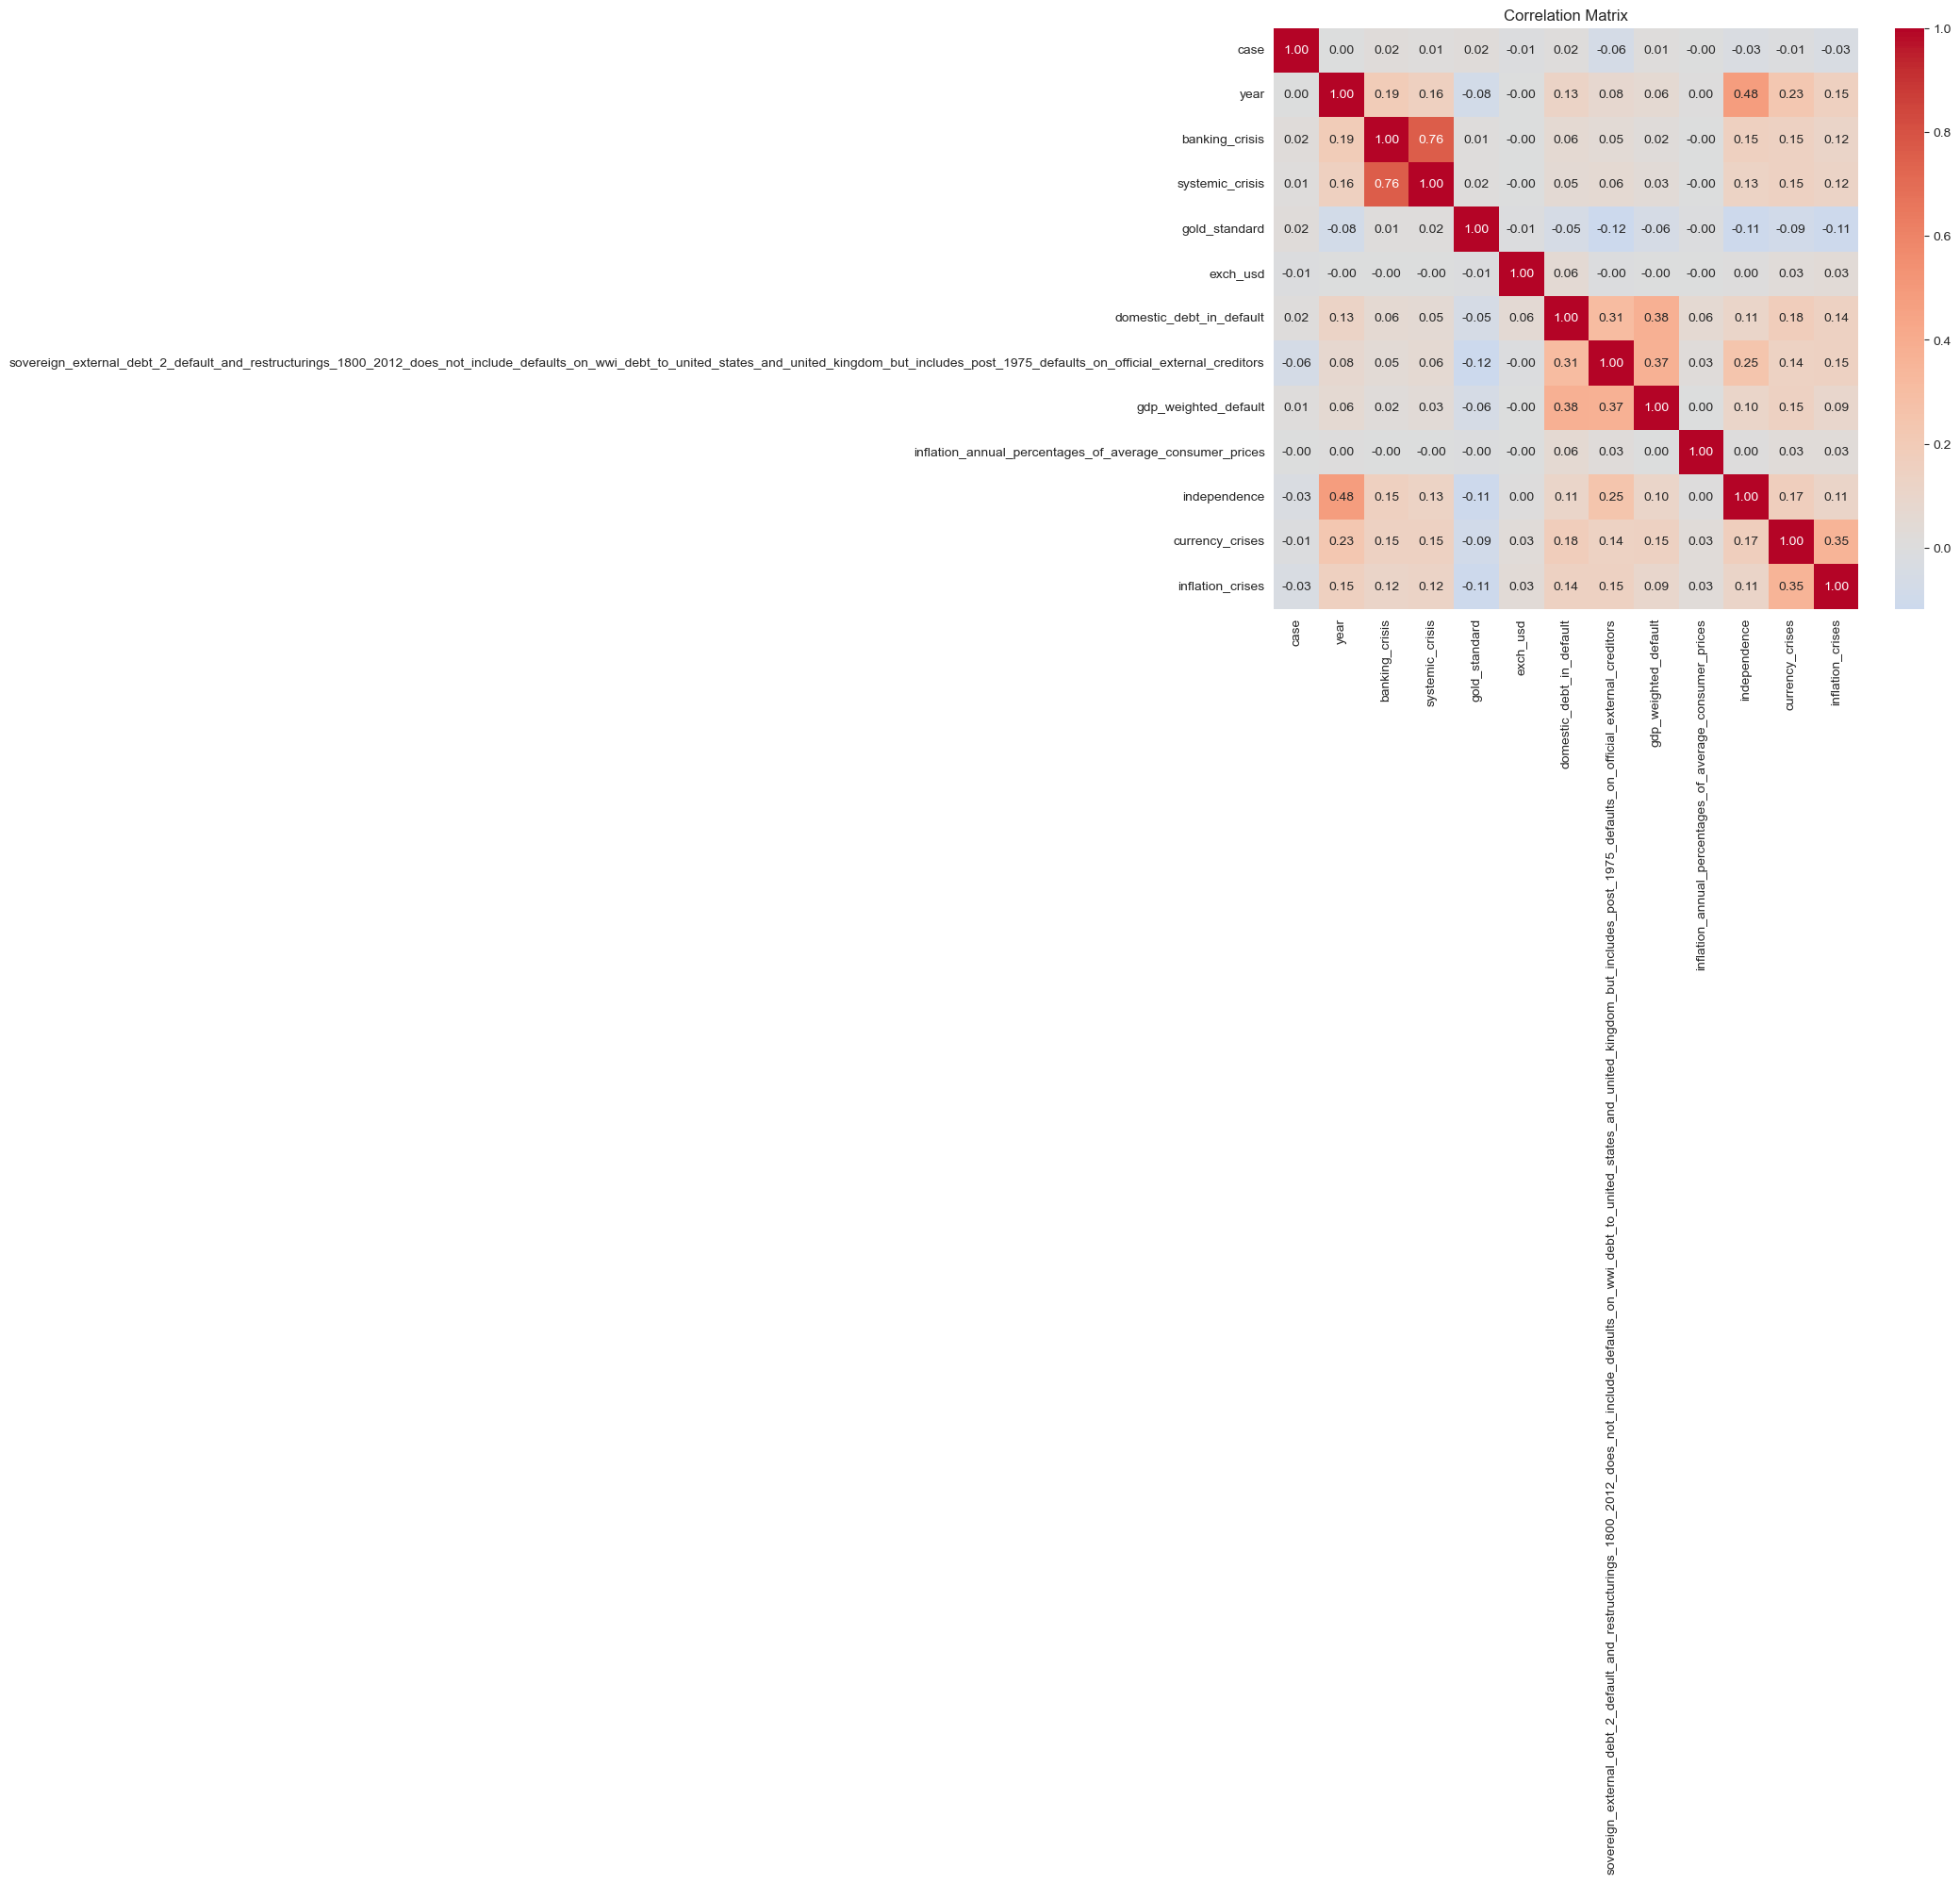

In [ ]:
# ============================================================
# 2.6 Correlation heatmap (Ch 3)
# ============================================================

numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
# 
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

The correlation matrix shows that most individual variables have relatively weak relationships with the target variable, suggesting that financial crises are not driven by any single factor. Instead, they likely result from a combination of economic conditions. One notable exception is the strong correlation between banking crises and systemic crises, which makes sense given that banking instability is often a core component of broader financial crises. There is also some moderate correlation among debt-related variables, indicating potential overlap in the information they capture. Overall, this suggests that more flexible models that can capture interactions between variables may perform better than simple linear approaches.

### YOUR TASK: Answer These 3 EDA Questions

1. **What is the distribution of your target variable?** Is it balanced (classification) or normally distributed (regression)? If not, what will you do about it?

   *Your answer:* The target variable is clearly imbalanced, with far more non-crisis observations than crisis events. This makes sense given that financial crises are relatively rare but significant events. Because of this imbalance, accuracy alone would be misleading, since a model could perform well by simply predicting no crisis most of the time. To deal with this, I’ll focus more on metrics like recall and F1-score, which better capture how well the model identifies actual crisis events.

2. **Which features appear most correlated with the target?** Are any features highly correlated with each other (multicollinearity)?  

   *Your answer:* Most features show relatively weak correlations with the target variable, which suggests that financial crises are not driven by any single factor. One exception is the strong relationship between banking crises and systemic crises, which is expected since banking instability is often part of a broader financial crisis. There are also some moderate correlations between debt-related variables, which could indicate overlapping information and potential multicollinearity. Overall, this suggests that combining multiple features will be important for making accurate predictions.

3. **What is the biggest data quality issue you found, and how will you handle it?**  

   *Your answer:* The biggest data quality issue is the amount of missing data in key variables, especially inflation and exchange rates, where a large portion of observations is missing. This likely reflects differences in data availability across countries and time periods. To handle this, I’ll use median imputation for numeric variables and consider dropping features that are too incomplete to be useful. I also had to convert some variables from text to numeric format, which introduced additional missing values. In addition, rows with missing values in the target variable were dropped before modeling, since those observations cannot be used in supervised learning.

In [ ]:
missing_percent = df.isnull().mean().mean() * 100
print(f"Total missing: {missing_percent:.2f}%")

Total missing: 7.48%


### 2.7 Data Quality Summary

**Data Quality Summary**

My dataset has **N = 15,190** observations and **M = 16** features.

**Missing data:** 7.48% of cells are missing. The missingness pattern appears to be MAR because gaps are concentrated in certain variables and likely reflect differences in data availability across countries and time periods. I will handle missing feature values using median imputation and will drop rows with missing values in the target variable before modeling, since those observations cannot be used to train or evaluate the model.

**Outliers:** I identified 1108 outliers using Tukey Fences. These values likely reflect real economic events, such as periods of extremely high inflation, rather than simple errors. Because of that, I will keep them and rely on models that are more robust to extreme values.

**Target variable:** The systemic crisis variable is highly imbalanced, with significantly more non-crisis observations than crisis events. This means accuracy alone would be misleading, so I will focus more on recall and F1-score when evaluating model performance.

**Key finding from EDA:** Financial crises appear to be rare and complex events that are not strongly predicted by any single variable. Instead, they seem to depend on a combination of economic conditions, which suggests that more flexible models will likely perform better.

This reinforces that predicting financial crises is a complex problem that likely requires combining multiple signals rather than relying on any single indicator.

---
## Part 3: Modeling

### 3.1 Train/Test Split

In [ ]:
# ============================================================
# 3.1 Train/test split (Ch 6)
# ============================================================

features = [
    'year',
    'exch_usd',
    'inflation_annual_percentages_of_average_consumer_prices',
    'gdp_weighted_default',
    'domestic_debt_in_default',
    'sovereign_external_debt_2_default_and_restructurings_1800_2012_does_not_include_defaults_on_wwi_debt_to_united_states_and_united_kingdom_but_includes_post_1975_defaults_on_official_external_creditors',
    'gold_standard',
    'independence',
    'currency_crises',
    'inflation_crises'
]

model_df = df[features + ['systemic_crisis']].copy()


model_df = model_df.dropna(subset=['systemic_crisis'])


X = model_df[features]
y = model_df['systemic_crisis']


X = X.fillna(X.median())


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape[0]} samples')
print(f'Test: {X_test.shape[0]} samples')
print(f'Missing values in target: {y.isnull().sum()}')

Train: 12095 samples
Test: 3024 samples
Missing values in target: 0


I split the dataset into training and testing sets using an 80/20 split. Since the target variable is highly imbalanced, I used stratified sampling to keep the proportion of crisis and non-crisis observations similar in both sets. Before splitting the data, I dropped rows with missing values in the target variable, since observations without a known crisis outcome cannot be used for supervised learning. Missing values in the feature set were then handled using median imputation.

### 3.2 Model 1: Baseline

In [ ]:
# ============================================================
# 3.2 Model 1 — Baseline
# ============================================================
# Choose a simple, interpretable baseline:
#   Classification: LogisticRegression
#   Regression: LinearRegression or Ridge

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


model_1 = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)


model_1.fit(X_train, y_train)


y_pred_1 = model_1.predict(X_test)


print("Model 1: Logistic Regression")
print(classification_report(y_test, y_pred_1))

Model 1: Logistic Regression
              precision    recall  f1-score   support

         0.0       0.96      1.00      0.98      2911
         1.0       0.00      0.00      0.00       113

    accuracy                           0.96      3024
   macro avg       0.48      0.50      0.49      3024
weighted avg       0.93      0.96      0.94      3024



/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no pred

The logistic regression model achieves a high overall accuracy of 96%, but this result is misleading due to the strong class imbalance in the dataset. The model predicts almost all observations as non-crisis cases, resulting in a recall of 0 for crisis events. This means the model completely fails to identify any actual financial crises, which makes it ineffective for the intended purpose.

This outcome highlights the limitations of using a standard logistic regression model on imbalanced data. Since crises are rare events, the model prioritizes overall accuracy rather than correctly identifying the minority class. As a result, metrics like recall and F1-score provide a more meaningful evaluation than accuracy in this context.

### 3.3 Model 2: Your Choice

In [ ]:
# ============================================================
# 3.3 Model 2 — Your choice
# ============================================================
# Choose a more flexible model:
from sklearn.ensemble import RandomForestClassifier

model_2 = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE
)

model_2.fit(X_train, y_train)

y_pred_2 = model_2.predict(X_test)

print("Model 2: Random Forest")
print(classification_report(y_test, y_pred_2))

Model 2: Random Forest
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.98      2911
         1.0       0.63      0.17      0.27       113

    accuracy                           0.97      3024
   macro avg       0.80      0.58      0.62      3024
weighted avg       0.96      0.97      0.96      3024



The Random Forest model improves significantly over logistic regression, particularly in its ability to detect crisis events. While overall accuracy remains high at 97%, the more important improvement is in the recall for crisis cases, which increases from 0 to 0.17. This indicates that the model is now able to identify at least some financial crises, whereas the logistic regression model failed to detect any.

The precision for crisis predictions is also relatively strong at 0.63, meaning that when the model predicts a crisis, it is often correct. However, the relatively low recall shows that many crisis events are still being missed. This reflects the inherent difficulty of predicting rare events like financial crises, but also demonstrates that more flexible models like Random Forest are better suited to capturing these patterns than simple linear models.

### 3.4 Cross-Validation Comparison

In [ ]:
# ============================================================
# 3.4 Cross-validation (Ch 15)
# ============================================================
scoring = 'f1'

cv_1 = cross_val_score(model_1, X_train, y_train, cv=5, scoring=scoring)
cv_2 = cross_val_score(model_2, X_train, y_train, cv=5, scoring=scoring)

print(f'Model 1 CV {scoring}: {cv_1.mean():.4f} +/- {cv_1.std():.4f}')
print(f'Model 2 CV {scoring}: {cv_2.mean():.4f} +/- {cv_2.std():.4f}')

comparison = pd.DataFrame({
    'Model': ['Model 1 (Baseline)', 'Model 2 (Random Forest)'],
    f'CV {scoring} (mean)': [cv_1.mean(), cv_2.mean()],
    f'CV {scoring} (std)': [cv_1.std(), cv_2.std()],
})
comparison

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_resu

Model 1 CV f1: 0.0000 +/- 0.0000
Model 2 CV f1: 0.2520 +/- 0.0572


,Model,CV f1 (mean),CV f1 (std)
0,Model 1 (Baseline),0.000000,0.0000
1,Model 2 (Random Forest),0.251961,0.0572


To get a more reliable estimate of model performance, I used 5-fold cross-validation on the training data. Since the dataset is highly imbalanced, I evaluated performance using the F1-score rather than accuracy.

The results show a clear difference between the two models. Logistic regression produces an F1-score of 0 across all folds, confirming that it is unable to detect crisis events. In contrast, the Random Forest model achieves an average F1-score of approximately 0.25, indicating that it is able to capture meaningful patterns related to financial crises.

While the overall performance is still limited, this is expected given the difficulty of predicting rare events. The relatively low standard deviation suggests that the Random Forest model performs consistently across different subsets of the data. Overall, these results reinforce that more flexible models are better suited for this problem than simple linear approaches.

---
## Part 4: Feature Importance + Visualization

### 4.1 Feature Importance

/var/folders/j3/nd_86gjn37l6zlf48np5tyx80000gn/T/ipykernel_99901/2115397717.py:24: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


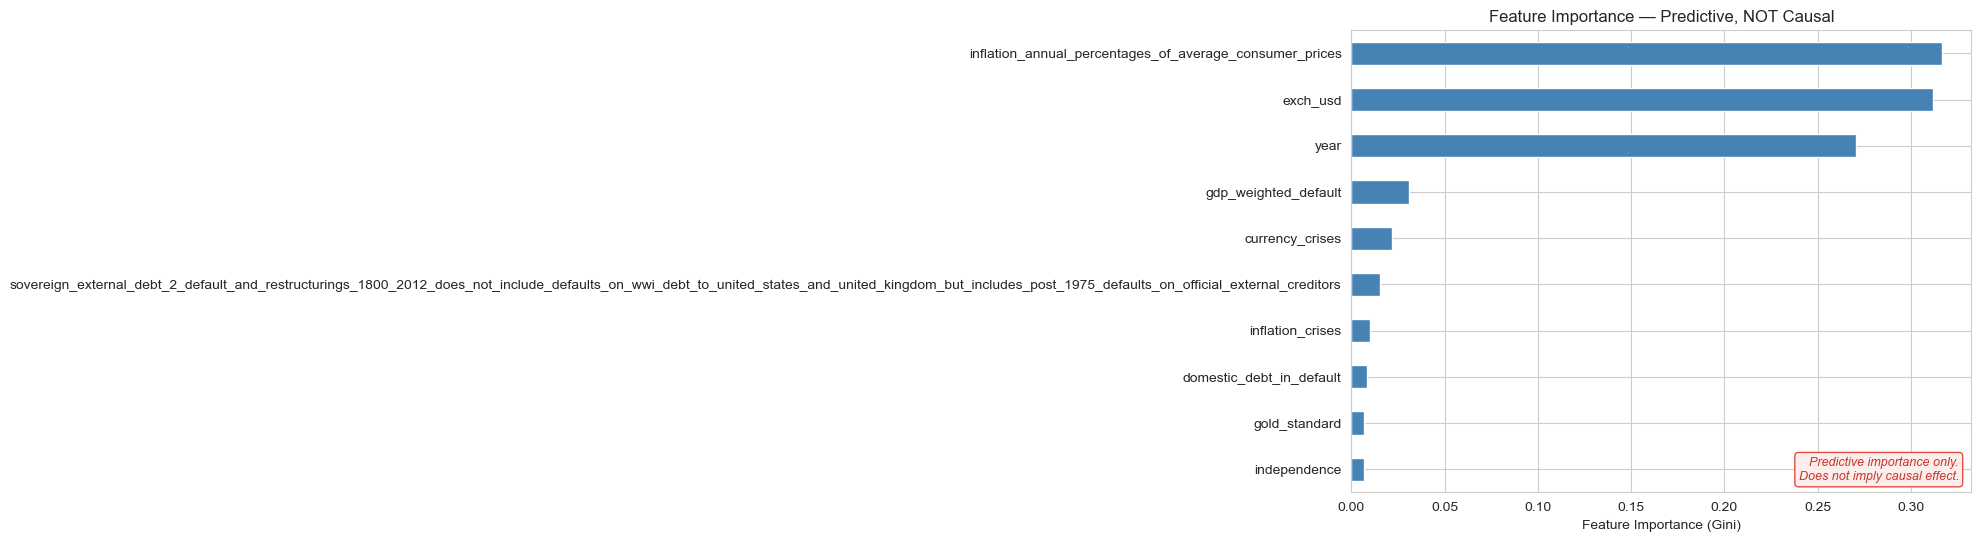

In [ ]:
# ============================================================
# 4.1 Feature importance (Ch 19)
# ============================================================

# # For tree-based models:
importances = pd.Series(
    model_2.feature_importances_, index=X.columns
).sort_values(ascending=True)
 
fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Feature Importance — Predictive, NOT Causal')
 
 # CRITICAL: Add the caveat banner
ax.text(
     0.98, 0.02,
    'Predictive importance only.\nDoes not imply causal effect.',
     transform=ax.transAxes, fontsize=9, ha='right', va='bottom',
     style='italic', color='#c0392b',
     bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdedec', edgecolor='#e74c3c')
 )
 
plt.tight_layout()
plt.show()

The feature importance plot highlights which variables the Random Forest model relied on most when making predictions. The most important predictors are inflation and exchange rates, followed by the year variable. This suggests that macroeconomic instability plays a key role in identifying patterns associated with financial crises.

Other variables, such as GDP-weighted default and currency crises, also contribute to the model, but to a lesser extent. In contrast, variables like independence and the gold standard appear to have very little influence on predictions.

These results are consistent with the idea that financial crises are closely tied to broader economic conditions rather than any single isolated factor. However, it is important to note that these importance values reflect predictive usefulness within the model, not causal relationships. A variable being highly ranked does not mean it directly causes financial crises, only that it helps the model make better predictions.

### 4.2 Key Visualization for Your Report

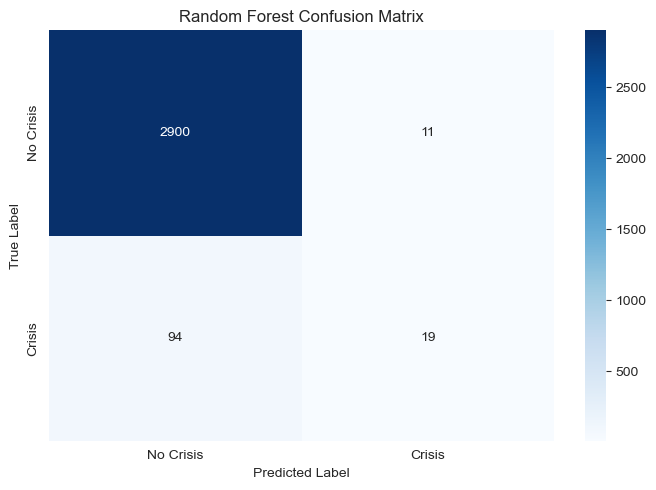

In [ ]:
# ============================================================
# 4.2 Your key visualization
# ============================================================
# This is the ONE chart you would put on the first page of your report.
# It should communicate your main finding clearly.
#
# Examples:
#   - Actual vs. predicted scatter (regression)
#   - Confusion matrix heatmap (classification)
#   - ROC curve comparison (classification)
#   - Partial dependence plot for top feature


from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_2)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Crisis', 'Crisis'],
    yticklabels=['No Crisis', 'Crisis']
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Random Forest Confusion Matrix')
plt.tight_layout()
plt.show()

The confusion matrix provides a clear view of how the Random Forest model performs across both classes. The model correctly identifies the vast majority of non-crisis observations, with very few false positives. This indicates strong performance in recognizing stable periods.

At the same time, the model is able to identify some financial crises, correctly predicting 19 crisis events. However, it still misses a large number of them, with 94 crisis cases incorrectly classified as non-crisis. This highlights the challenge of predicting rare events, where the model tends to be conservative and only flags crises when it is relatively confident.

Overall, the confusion matrix shows that while the model performs well in general classification, its ability to detect crises is limited but improved compared to simpler models. This makes it a useful tool, but one that would need further refinement for real-world decision-making.

---
## Part 5: Recommendation

Use the SCR (Situation-Complication-Resolution) structure from Chapter 26.

**Situation:** Policymakers and international organizations, such as the IMF, need to decide when to intervene in countries that may be at risk of a financial crisis. These decisions are difficult because crises are rare and often develop from a combination of economic factors rather than a single clear signal. Having a model that can identify early warning signs could help guide more proactive and targeted interventions.

**Complication:** The main challenge is that financial crises are both rare and complex, which makes them difficult to predict accurately. The data is highly imbalanced, with far more non-crisis observations than crisis events, and no single variable strongly predicts crises on its own. The initial logistic regression model performed poorly, failing to identify any crisis events. While the Random Forest model improves on this by detecting some crises, it still misses a significant number of them. This highlights the uncertainty and difficulty involved in predicting rare economic events.

**Resolution:** Based on the results, I recommend using the Random Forest model as a starting point for identifying potential crisis risk, since it is able to detect meaningful patterns that simpler models cannot. The model performs well at identifying stable periods and shows some ability to flag crisis events, particularly when macroeconomic instability is present. While it is not perfect, it provides a more useful signal than baseline approaches and can serve as an early warning tool to guide further investigation or policy response.

**Uncertainty Statement:** Based on our cross-validation results (F1-score = 0.25 +/- 0.06), we estimate that the model has limited but consistent ability to identify financial crises. The primary limitation is the low recall, meaning that many crisis events are still missed. We recommend using this model as a supplementary tool rather than a standalone decision-maker, with the caveat that that improving detection of rare events should be a key focus in future model development.

---
## Part 6: Streamlit Export Guide

### 6.1 Creating app.py

Your Streamlit app should contain:
1. **Title and description** — `st.title()`, `st.markdown()`
2. **Input controls** — `st.slider()`, `st.selectbox()`, `st.number_input()`
3. **Model prediction** — load your trained model, generate predictions from user inputs
4. **Visualization** — at least one chart that updates with user inputs
5. **Uncertainty** — display confidence/prediction intervals alongside point estimates

### 6.2 Minimal app.py Template

```python
import streamlit as st
import pandas as pd
import numpy as np
import joblib  # to load saved model

st.title('Your Project Title')
st.markdown('Brief description of what this app predicts.')

# Sidebar controls
feature_1 = st.sidebar.slider('Feature 1', min_value=0.0, max_value=100.0, value=50.0)
feature_2 = st.sidebar.selectbox('Feature 2', ['Option A', 'Option B', 'Option C'])

# Load model (save with joblib.dump(model, 'model.pkl') in your notebook)
model = joblib.load('model.pkl')

# Predict
input_data = pd.DataFrame({'feature_1': [feature_1], 'feature_2': [feature_2]})
prediction = model.predict(input_data)[0]

st.metric('Prediction', f'{prediction:.2f}')
```

### 6.3 requirements.txt Template

```
streamlit>=1.31.0
pandas>=2.0.0
numpy>=1.24.0
scikit-learn>=1.4.0
matplotlib>=3.7.0
seaborn>=0.12.0
joblib>=1.3.0
```

### 6.4 Deployment Steps

1. Save your model: `joblib.dump(model_2, 'model.pkl')`
2. Test locally: `streamlit run app.py`
3. Push to GitHub: `app.py`, `model.pkl`, `requirements.txt`
4. Go to [streamlit.io/cloud](https://streamlit.io/cloud) and deploy
5. Submit the permanent URL on Canvas

In [63]:
import joblib

joblib.dump(model_2, 'model.pkl')

['model.pkl']

In [64]:
feature_names = X_train.columns.tolist()
joblib.dump(feature_names, 'feature_names.pkl')

['feature_names.pkl']

---
## Part 7: AI Methodology Appendix

Document at least **3 AI interactions** using the P.R.I.M.E. framework. Copy and fill in the template below for each interaction.

---

### AI Interaction 1

**Prep:** What did you need? What context did you have before prompting?
> I needed help selecting an appropriate dataset and defining a clear prediction problem for my final project. I knew I wanted to work on something related to financial crises, but I had not yet identified a dataset or clearly distinguished between a prediction and causal question.

**Request:** What exact prompt did you write?
> "Can you suggest a dataset and project idea for predicting financial crises that would fit a statistical machine learning project?"

**Iterate:** What did the AI return? What did you change or refine?
> The AI suggested using a global financial crisis dataset and framing the problem as predicting whether a country experiences a systemic crisis. I refined the idea by narrowing the prediction question to a binary classification problem and identifying the stakeholder as policymakers or institutions like the IMF.

**Mechanism Check:** How did you verify the output was correct?
> I verified that the dataset contained a clearly defined target variable (systemic_crisis) and appropriate features by loading it into a DataFrame and checking its structure using .info() and .describe().

**Evaluate:** What human judgment did you apply? What did you accept/reject and why?
> I accepted the dataset suggestion because it aligned well with course concepts and provided a realistic prediction problem. I also adjusted the framing to make sure it clearly emphasized prediction rather than causation, which is important for this assignment.

---

### AI Interaction 2

**Prep:** After completing initial EDA, I needed help building my first machine learning model and interpreting the results. I was unsure how to handle class imbalance and which metrics were most appropriate for evaluation.

**Request:** "Help me build a baseline classification model for this dataset and explain how to evaluate it, especially given that the target variable is imbalanced."

**Iterate:** The AI provided code for a logistic regression model and suggested using accuracy, precision, recall, and F1-score. After seeing that the model achieved high accuracy but failed to detect any crisis events, I refined my approach by focusing more on recall and F1-score rather than accuracy.

**Mechanism Check:** I verified the results by running the model and examining the classification report. I confirmed that recall for the crisis class was 0, which matched the explanation that the model was predicting only the majority class.

**Evaluate:** I rejected accuracy as the primary metric and instead focused on recall and F1-score for evaluation. I also decided to move to a more flexible model (Random Forest) based on the AI’s suggestion that linear models struggle with imbalanced data.

---

### AI Interaction 3

**Prep:** After seeing the limitations of logistic regression, I needed to improve model performance, particularly in detecting crisis events.


**Request:** "What model should I use to improve performance on an imbalanced classification problem like this?"


**Iterate:** The AI suggested using a Random Forest classifier due to its ability to capture nonlinear relationships. I implemented the model and adjusted parameters such as the number of estimators. I also compared performance against the baseline model.


**Mechanism Check:** I verified the improvement by comparing classification reports and cross-validation scores. The Random Forest model showed a meaningful increase in recall and F1-score for the crisis class.


**Evaluate:** I accepted the Random Forest model as the final model because it provided better performance on the minority class. However, I recognized that it still had limitations, particularly in recall, and interpreted the results accordingly.

---

### AI Interaction 4

**Prep:** Once my models were complete, I needed to deploy the project using Streamlit. I had no prior experience building or deploying a web app, so I needed guidance on structuring the app and connecting it to my trained model.

**Request:** "Can you help me turn my trained model into a Streamlit app that allows users to input features and see predictions?"

**Iterate:** The AI provided a template for app.py, including input controls, model loading, prediction output, and a simple visualization. I refined the app by adjusting feature inputs, improving labeling for usability, and adding an uncertainty range based on cross-validation results.

**Mechanism Check:** I tested the app locally using streamlit run app.py and confirmed that inputs updated predictions correctly. I also deployed the app on Streamlit Cloud and verified that it worked in a live environment without errors.

**Evaluate:** I accepted the structure of the app but modified variable names and descriptions to make them more user-friendly. I also added an uncertainty component and visualization to meet assignment requirements and improve interpretability.



